# Laboratorio 3 — Rendimiento de una bomba de calor

**ICF130, Fundamentos de la Termodinámica**

**Autores:** Ignacio Díaz · Flavia Pedraza

---

Se mide el desempeño de un compresor que transfiere calor entre dos depósitos de agua. El
**foco frío** ($T_1$) se enfría y el **foco caliente** ($T_2$) se calienta, mientras se registra
la potencia eléctrica consumida por el compresor.

El calor entregado al foco caliente en cada intervalo se obtiene de su cambio de temperatura, y
el trabajo eléctrico del producto de la potencia por el tiempo:

$$
Q_2 = m c_p \Delta T_2, \qquad W_{elec} = P \Delta t, \qquad \eta_{co} = \frac{Q_2}{W_{elec}}
$$

**Propagación de errores.** La incertidumbre de una diferencia de dos medidas independientes es
$\delta(\Delta T) = \sqrt{2}\,\delta T$. Como $\eta_{co}$ es un producto de cocientes, su error
relativo se compone en cuadratura:

$$
\frac{\delta\eta}{\eta} = \sqrt{\left(\frac{\delta(\Delta T_2)}{\Delta T_2}\right)^2 + \left(\frac{\delta P}{P}\right)^2 + \left(\frac{\delta(\Delta t)}{\Delta t}\right)^2}
$$

## Datos y cálculo

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Datos experimentales ----
df = pd.DataFrame({
    "t_s":  [0, 60, 120, 180, 240, 300, 360, 420, 480, 540, 600],
    "T1":   [22, 21, 20, 17, 17, 15, 14, 12, 11, 11, 10],      # foco frio  [C]
    "T2":   [21, 22, 24, 26, 27, 29, 30, 32, 34, 35, 36],      # foco caliente [C]
    "P_W":  [118.2, 109.1, 110.9, 114.6, 114.9, 115.6, 115.6, 114.2, 120.9, 117.6, 121.1],
})

# ---- Constantes ----
m_agua = 2.0      # kg
c_p    = 4186.0   # J/(kg K)
dt     = 60.0     # s, duracion de cada intervalo

# ---- Incertidumbres instrumentales ----
d_T = 1.0    # termometro   [C]
d_t = 1.0    # cronometro   [s]
d_P = 0.1    # potencia     [W]

# Incertidumbre de una diferencia de dos medidas independientes
d_dT = np.sqrt(2) * d_T
d_dt = np.sqrt(2) * d_t

# ---- Rendimiento por intervalo, con propagacion de error ----
filas, W_acumulado = [], 0.0

for i in range(1, len(df)):
    dT2 = df["T2"][i] - df["T2"][i - 1]
    P   = df["P_W"][i - 1]          # potencia al inicio del intervalo

    Q2     = m_agua * c_p * dT2
    W_elec = P * dt
    W_acumulado += W_elec
    eta = Q2 / W_elec

    err_rel = np.sqrt((d_dT / dT2) ** 2 + (d_P / P) ** 2 + (d_dt / dt) ** 2) if dT2 else np.nan

    filas.append({"t [min]": df["t_s"][i] / 60, "dT2 [C]": dT2, "P [W]": P,
                  "eta": eta, "d_eta": eta * err_rel, "error [%]": 100 * err_rel})

tabla = pd.DataFrame(filas)

# ---- Rendimiento global ----
dT2_total  = df["T2"].iloc[-1] - df["T2"].iloc[0]
eta_global = m_agua * c_p * dT2_total / W_acumulado
err_global = eta_global * np.sqrt((d_dT / dT2_total) ** 2 + (d_P / df["P_W"].mean()) ** 2
                                  + (d_dt / df["t_s"].iloc[-1]) ** 2)

display(tabla.style.format({"t [min]": "{:.0f}", "dT2 [C]": "{:.0f}", "P [W]": "{:.1f}",
                            "eta": "{:.2f}", "d_eta": "{:.2f}",
                            "error [%]": "{:.0f}"}).hide(axis="index"))

print(f"Rendimiento global: eta = {eta_global:.2f} +/- {err_global:.2f}  "
      f"({100*err_global/eta_global:.1f} %)")

# ---- Verificacion termodinamica ----
T2_K = df["T2"].iloc[-1] + 273.15
T1_K = df["T1"].iloc[-1] + 273.15
cop_carnot = T2_K / (T2_K - T1_K)
print(f"Limite de Carnot al final del ensayo: COP = T2/(T2-T1) = {cop_carnot:.1f}")
print()
print("Que eta supere la unidad es lo esperado: no es una eficiencia acotada por 1, sino un")
print("coeficiente de desempeno. La maquina no crea energia, la transporta desde el foco frio.")
print("El valor medido queda muy por debajo del limite de Carnot, como corresponde a una")
print("maquina real con irreversibilidades.")

t [min],dT2 [C],P [W],eta,d_eta,error [%]
1,1,118.2,1.18,1.67,141
2,2,109.1,2.56,1.81,71
3,2,110.9,2.52,1.78,71
4,1,114.6,1.22,1.72,141
5,2,114.9,2.43,1.72,71
6,1,115.6,1.21,1.71,141
7,2,115.6,2.41,1.71,71
8,2,114.2,2.44,1.73,71
9,1,120.9,1.15,1.63,141
10,1,117.6,1.19,1.68,141


Rendimiento global: eta = 1.82 +/- 0.17  (9.4 %)
Limite de Carnot al final del ensayo: COP = T2/(T2-T1) = 11.9

Que eta supere la unidad es lo esperado: no es una eficiencia acotada por 1, sino un
coeficiente de desempeno. La maquina no crea energia, la transporta desde el foco frio.
El valor medido queda muy por debajo del limite de Carnot, como corresponde a una
maquina real con irreversibilidades.


## Gráficos

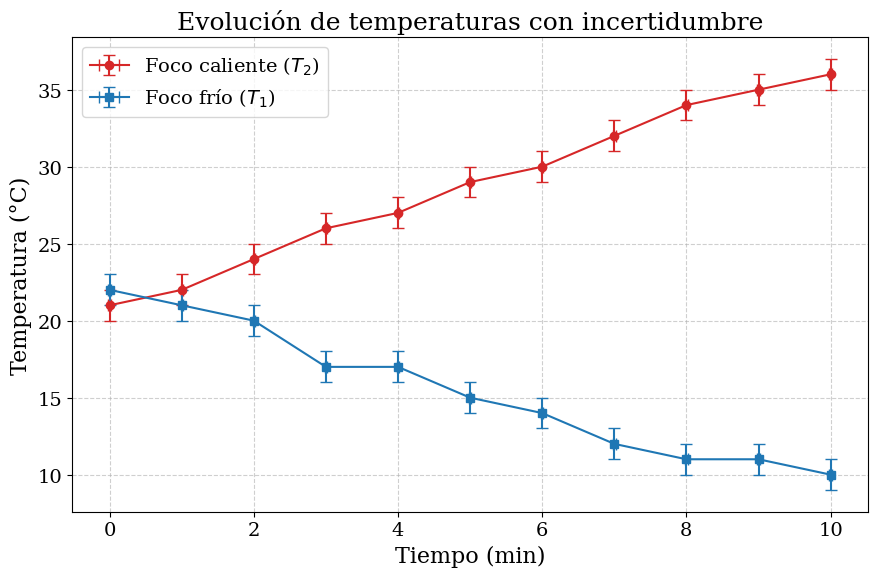

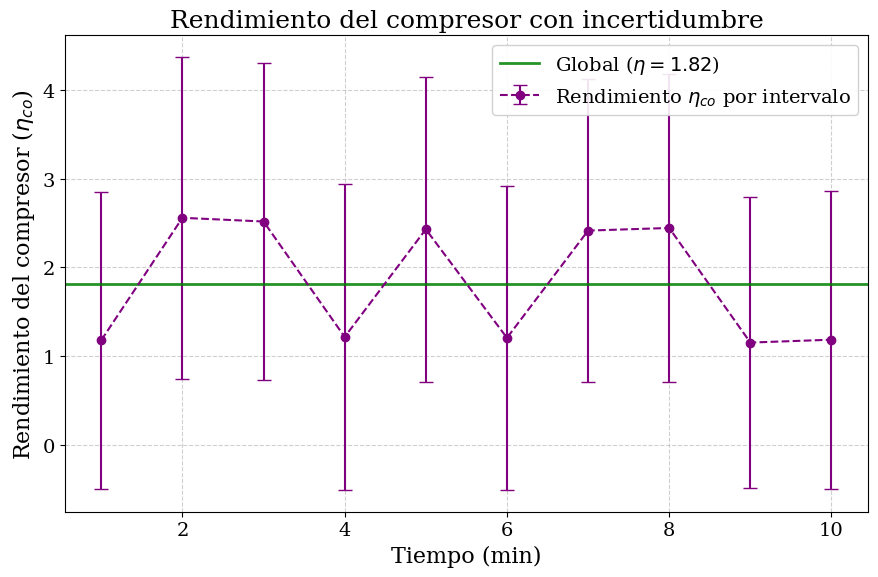

In [2]:
plt.rcParams.update({"font.size": 14, "font.family": "serif"})

# ---- Evolucion de ambos focos ----
plt.figure(figsize=(9, 6))
plt.errorbar(df["t_s"] / 60, df["T2"], yerr=d_T, xerr=d_t / 60, fmt="o-",
             color="#D62728", label=r"Foco caliente ($T_2$)", capsize=4, markersize=6)
plt.errorbar(df["t_s"] / 60, df["T1"], yerr=d_T, xerr=d_t / 60, fmt="s-",
             color="#1F77B4", label=r"Foco frío ($T_1$)", capsize=4, markersize=6)
plt.xlabel("Tiempo (min)", fontsize=16)
plt.ylabel("Temperatura (°C)", fontsize=16)
plt.title("Evolución de temperaturas con incertidumbre", fontsize=18)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig("temperaturas_vs_tiempo.png", dpi=300)
plt.show()

# ---- Rendimiento por intervalo ----
plt.figure(figsize=(9, 6))
plt.errorbar(tabla["t [min]"], tabla["eta"], yerr=tabla["d_eta"], fmt="o--",
             color="purple", ecolor="purple", capsize=5, elinewidth=1.5,
             label=r"Rendimiento $\eta_{co}$ por intervalo", markersize=6)
plt.axhline(eta_global, color="green", lw=2, alpha=0.85,
            label=rf"Global ($\eta = {eta_global:.2f}$)")
plt.xlabel("Tiempo (min)", fontsize=16)
plt.ylabel(r"Rendimiento del compresor ($\eta_{co}$)", fontsize=16)
plt.title("Rendimiento del compresor con incertidumbre", fontsize=18)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper right", framealpha=0.9, fontsize=14)
plt.tight_layout()
plt.savefig("rendimiento_vs_tiempo.png", dpi=300)
plt.show()